# Network Data Analysis I
<br>
Objectives:
<br>
1. Are there any highly correlated (80%+) fields that should be condensed down to only one of them being included?
<br>
2. Are there any features that should be added that we don’t currently include
 (look at global_schema in /src/repositories/graphs/pyg_builder.py to see current fields being used)?
<br>
3. What does the distribution of “port_number” look like?
<br>
4. What is the overall range?
<br>
5. Do they naturally cluster into distinct groups?<br>
<br>
Data Source:
<br>
Collected from an automated industrial monitoring system, containing timestamped readings of tank levels, pump states, valve activations, flow sensor outputs, and labeled system states.
<br> <br>
File: attack_1.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
try:
    df = pd.read_csv('/attack_1.csv', sep=",", encoding='utf-8', engine="python")
except UnicodeDecodeError:
        print("UnicodeDecodeError")

## Part I - Enumerate Network Fields

In [4]:
# Initial Overview
print(df.head())

                         Time              mac_s              mac_d  \
0  2021-04-09 18:23:28.385003  74:46:a0:bd:a7:1b  0a:fe:ec:47:74:fb   
1  2021-04-09 18:23:28.385005  74:46:a0:bd:a7:1b  e6:3f:ac:c9:a8:8c   
2  2021-04-09 18:23:28.385006  74:46:a0:bd:a7:1b  fa:00:bc:90:d7:fa   
3  2021-04-09 18:23:28.385484  0a:fe:ec:47:74:fb  74:46:a0:bd:a7:1b   
4  2021-04-09 18:23:28.385486  fa:00:bc:90:d7:fa  74:46:a0:bd:a7:1b   

           ip_s          ip_d    sport    dport   proto    flags   size  \
0   84.3.251.20  84.3.251.102  56667.0    502.0  Modbus  11000.0     66   
1   84.3.251.20  84.3.251.101  56666.0    502.0  Modbus  11000.0     66   
2   84.3.251.20  84.3.251.103  56668.0    502.0  Modbus  11000.0     66   
3  84.3.251.102   84.3.251.20    502.0  56667.0  Modbus  11000.0     64   
4  84.3.251.103   84.3.251.20    502.0  56668.0  Modbus  11000.0     64   

             modbus_fn   n_pkt_src   n_pkt_dst  modbus_response   label_n  \
0   Read Coils Request         0.0         0.

In [5]:
# General data structures
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5527409 entries, 0 to 5527408
Data columns (total 16 columns):
 #   Column            Dtype  
---  ------            -----  
 0   Time              object 
 1    mac_s            object 
 2    mac_d            object 
 3    ip_s             object 
 4    ip_d             object 
 5    sport            float64
 6    dport            float64
 7    proto            object 
 8    flags            float64
 9    size             int64  
 10   modbus_fn        object 
 11   n_pkt_src        float64
 12   n_pkt_dst        float64
 13   modbus_response  object 
 14   label_n          int64  
 15   label            object 
dtypes: float64(5), int64(2), object(9)
memory usage: 674.7+ MB
None


In [6]:
print(df.columns.tolist())

['Time', ' mac_s', ' mac_d', ' ip_s', ' ip_d', ' sport', ' dport', ' proto', ' flags', ' size', ' modbus_fn', ' n_pkt_src', ' n_pkt_dst', ' modbus_response', ' label_n', ' label']


In [7]:
# Cleaning and Preprocessing
df.isnull().sum().sort_values(ascending=False)
df.columns = df.columns.str.strip()   #clean column names of whitespace

Modbus_response is sparsely present, seemingly only appearing for Modbus responses. This variable should be treated as conditional. Modbus_fn is missing in some flows, so it's likely on present for Modbus traffic. We could filter or impute for this variable if need be. There are minor gaps for dport, sport and flags, which may be due to malformed packets or non-TCP/UDP traffic, so we can likely drop or fill this for some analyses. There are a small number of missing values for n_pkt_src, n_pkt_dst, ip_s and ip_d, which may be due to incomplete flows, so these can either be dropped or imputed. Time, mac_s, mac_d, proto, size, label_n and label are all fully populated, and thus are safe to directly use.

In [8]:
df.describe(include='all')

,Time,mac_s,mac_d,ip_s,ip_d,sport,dport,proto,flags,size,modbus_fn,n_pkt_src,n_pkt_dst,modbus_response,label_n,label
count,5527409,5527409,5527409,5526934,5526934,5.526894e+06,5.526894e+06,5527409,5.526894e+06,5.527409e+06,5374286,5.526934e+06,5.526934e+06,2687227,5.527409e+06,5527409
unique,5242099,8,9,7,7,NaN,NaN,4,NaN,NaN,4,NaN,NaN,2947,NaN,4
top,2021-04-09 18:42:53.477313,74:46:a0:bd:a7:1b,74:46:a0:bd:a7:1b,84.3.251.20,84.3.251.20,NaN,NaN,Modbus,NaN,NaN,Read Holding Registers Response,NaN,NaN,[0],NaN,normal
freq,4,2678457,2678456,2678448,2678456,NaN,NaN,5374286,NaN,NaN,1430074,NaN,NaN,1655476,NaN,3687410
mean,NaN,NaN,NaN,NaN,NaN,2.849674e+04,2.837012e+04,NaN,1.091689e+04,6.532781e+01,NaN,3.070677e+01,3.074328e+01,NaN,3.328863e-01,NaN
std,NaN,NaN,NaN,NaN,NaN,2.796624e+04,2.798476e+04,NaN,8.398618e+02,1.400719e+00,NaN,1.756813e+01,1.753642e+01,NaN,4.712463e-01,NaN
min,NaN,NaN,NaN,NaN,NaN,2.500000e+01,2.500000e+01,NaN,1.000000e+01,6.000000e+01,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,NaN
25%,NaN,NaN,NaN,NaN,NaN,5.020000e+02,5.020000e+02,NaN,1.100000e+04,6.500000e+01,NaN,1.500000e+01,1.500000e+01,NaN,0.000000e+00,NaN
50%,NaN,NaN,NaN,NaN,NaN,3.499100e+04,5.020000e+02,NaN,1.100000e+04,6.600000e+01,NaN,1.900000e+01,1.900000e+01,NaN,0.000000e+00,NaN
75%,NaN,NaN,NaN,NaN,NaN,5.666700e+04,5.666700e+04,NaN,1.100000e+04,6.600000e+01,NaN,5.000000e+01,5.000000e+01,NaN,1.000000e+00,NaN


#Part II - Visualize Data

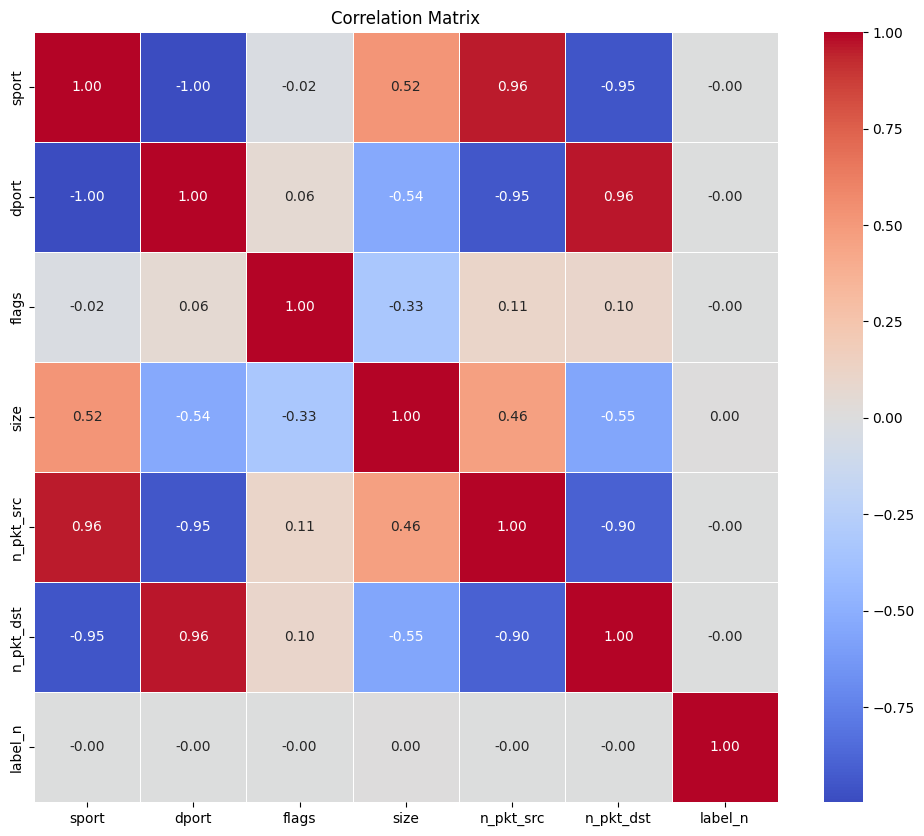

In [9]:
# Compute correlation matrix (pairwise Pearson correlations between numberic fields)
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

In [10]:
# Find highly-correlated pairs > 0.8
# Unstack and filter
high_corr = corr_matrix.abs().unstack().sort_values(ascending=False)
high_corr = high_corr[high_corr < 1.0]  # exclude self-correlation
high_corr = high_corr[high_corr > 0.8]

# Drop duplicate pairs
high_corr = high_corr[~high_corr.index.duplicated()]
print("Highly correlated pairs (> 0.8):")
print(high_corr)

Highly correlated pairs (> 0.8):
dport      sport        0.996847
sport      dport        0.996847
dport      n_pkt_dst    0.961287
n_pkt_dst  dport        0.961287
n_pkt_src  sport        0.957858
sport      n_pkt_src    0.957858
           n_pkt_dst    0.950938
n_pkt_dst  sport        0.950938
n_pkt_src  dport        0.945997
dport      n_pkt_src    0.945997
n_pkt_src  n_pkt_dst    0.902483
n_pkt_dst  n_pkt_src    0.902483
dtype: float64


We could drop or merge sport and dport by keeping only one or by creating a categorical role-based field like client_port or server_port. n_pkt_src and n_pkt_dst could also be combined into n_pkt_total. Additionally, we could consider creating is_ephemeral_port as a binary flag for ports greater than 49152. port_role could be created as a categorical feature for ports. For example, a port's role could be labeled "well-known", "registered" or "dynamic". Last, we could add a feature of traffic_directionality to tell us about a port's path, and this could be calculated via the ratio of n_pkt_src to n_pkt_dst.

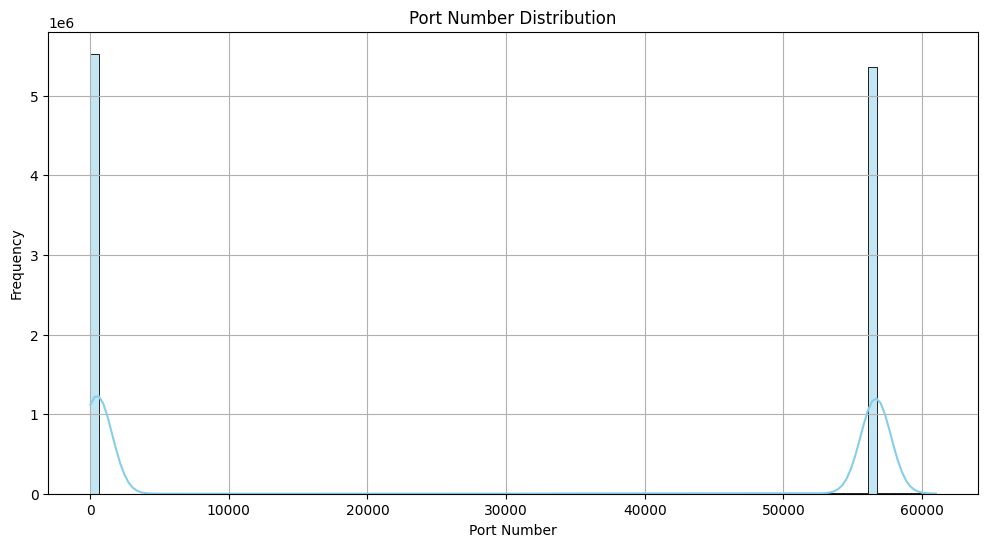

In [ ]:
# Combine port data
ports = pd.concat([df['sport'], df['dport']], ignore_index=True).dropna()

# Plot histogram and KDE
plt.figure(figsize=(12, 6))
sns.histplot(ports, bins=100, kde=True, color='skyblue')
plt.title('Port Number Distribution')
plt.xlabel('Port Number')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Clients initiate many connections, but there's few registered ports for user applications and services. Well-known ports reserved for standard services are the most frequent.

In [ ]:
# Ports binned into categories
def bin_port(port):
    if pd.isna(port):
        return 'missing'
    elif port <= 1023:
        return 'well_known'
    elif port <= 49151:
        return 'registered'
    else:
        return 'ephemeral'

df['sport_bin'] = df['sport'].apply(bin_port)
df['dport_bin'] = df['dport'].apply(bin_port)

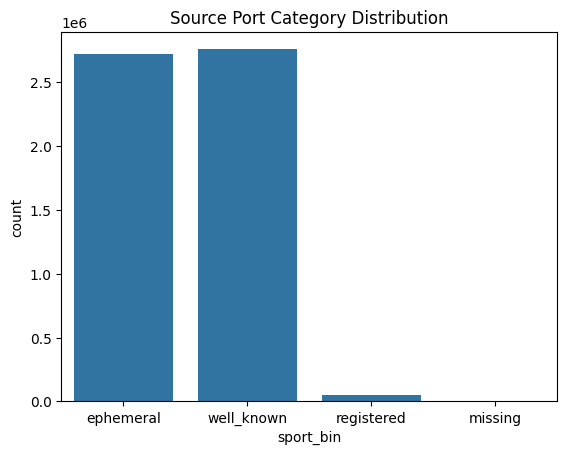

In [ ]:
# Visualize binned categories
sns.countplot(x='sport_bin', data=df)
plt.title('Source Port Category Distribution')
plt.show()

In [ ]:
# Frequency of Each Protocol
plt.figure(figsize=(10, 6))
sns.countplot(x='proto', data=df, order=df['proto'].value_counts().index)
plt.title('Protocol Frequency')
plt.xlabel('Protocol')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Pre-aggregate to reduce memory
agg = df.groupby(['sport', 'dport']).size().reset_index(name='count')
pivot = agg.pivot(index='sport', columns='dport', values='count').fillna(0)

In [ ]:
# Number of Connections per IP
ip_counts = df['ip_s'].value_counts().reset_index()
ip_counts.columns = ['ip_s', 'connection_count']

plt.figure(figsize=(12, 6))
sns.histplot(ip_counts['connection_count'], bins=50, kde=True, color='teal')
plt.title('Connections per Source IP')
plt.xlabel('Number of Connections')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

In [ ]:
# Source vs. Destination Ports
port_matrix = df.groupby(['sport', 'dport']).size().unstack(fill_value=0)

plt.figure(figsize=(12, 10))
sns.heatmap(port_matrix, cmap='magma', cbar_kws={'label': 'Connection Count'})
plt.title('Traffic Patterns: Source Port vs Destination Port')
plt.xlabel('Destination Port')
plt.ylabel('Source Port')
plt.tight_layout()
plt.show()